#  Customer Churn Prediction (Classification)


***Problem Statement***

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Problem Statement
Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features such as:

● Customer Age

● Gender

● Tenure

● Monthly Charges

● Total Charges

● Contract Type

● Payment Method

● Internet Service

● Tech Support

● Online Security

● Customer Support Calls

Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting customer churn.


***Objective***

The objective of this task is to:

● Understand and explore the customer dataset

● Perform data preprocessing (missing values, duplicates, outliers)

● Conduct Exploratory Data Analysis (EDA)

● Apply encoding and feature scaling

● Train multiple classification algorithms

● Evaluate models using classification metrics

● Perform cross-validation and hyperparameter tuning

● Select the best-performing model

**Import Libraries**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

**Load Dataset**

In [7]:
df = pd.read_csv('/content/drive/MyDrive/telecom_churn_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


**Check Dataset**

In [8]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non

**Handle Missing Values**

In [9]:
df.isnull().sum()

# Fill or drop (example)
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_3148/381530483.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


**Remove Duplicates**

In [10]:
df = df.drop_duplicates()

**Univariate Analysis**

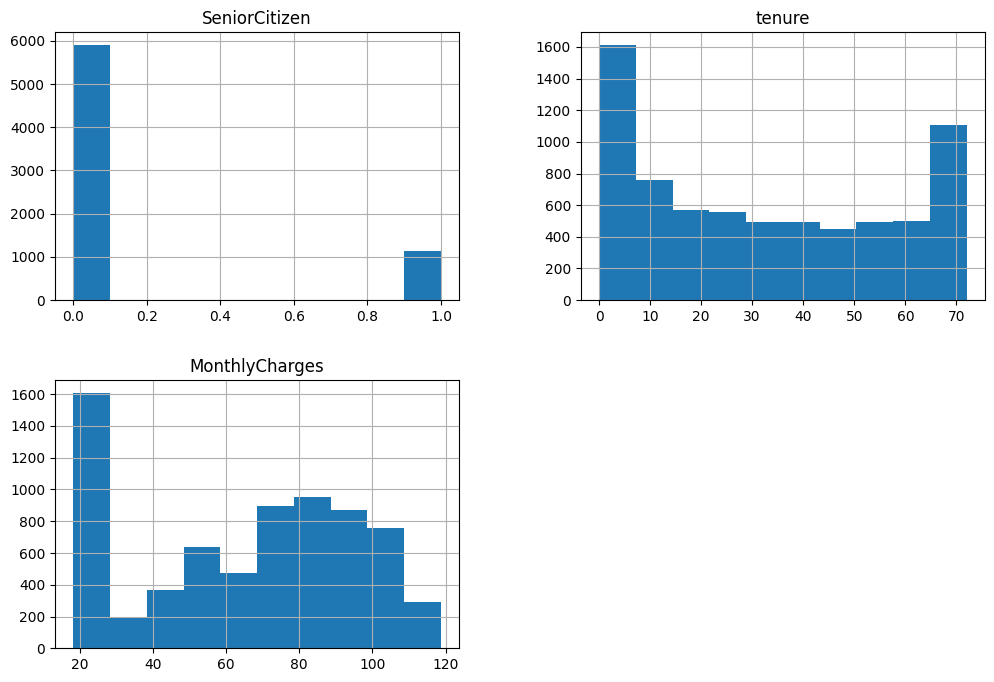

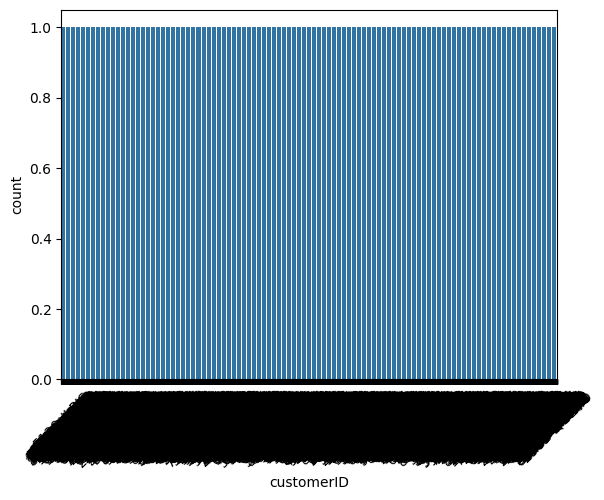

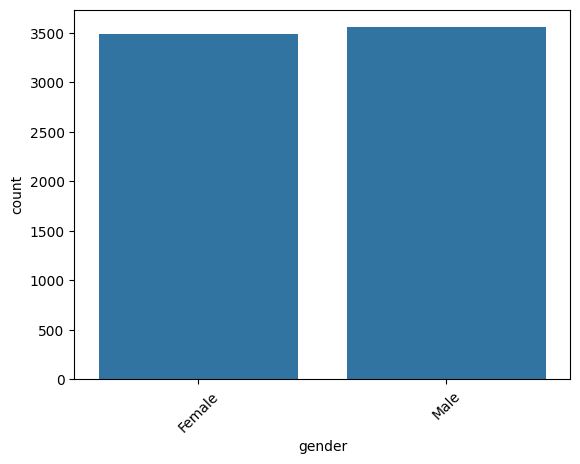

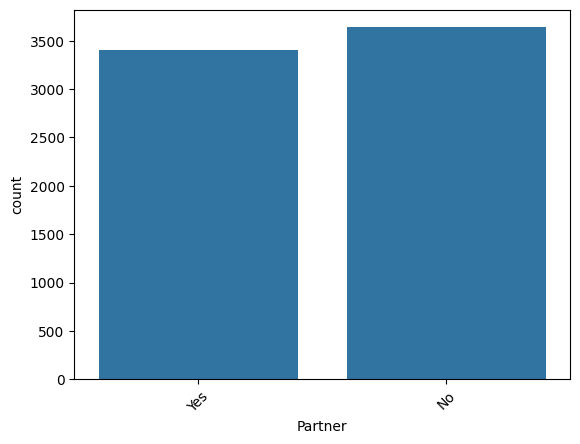

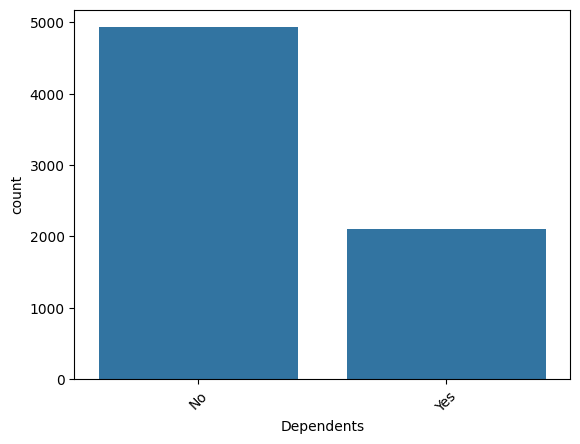

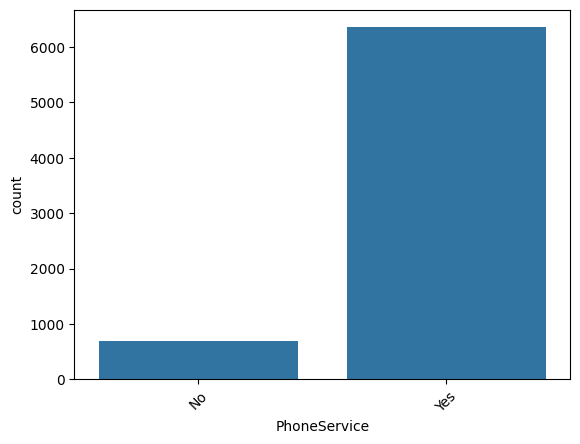

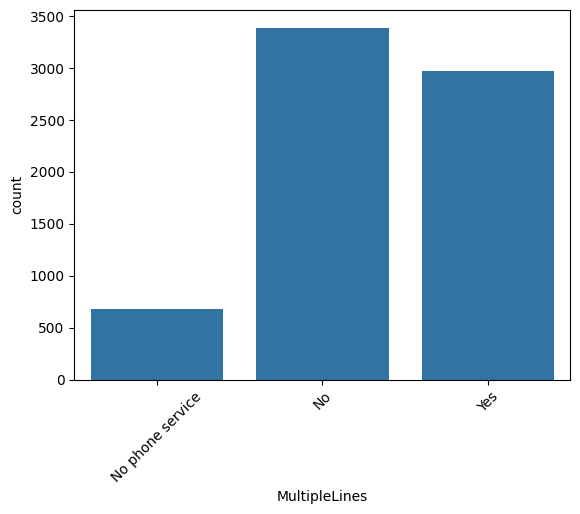

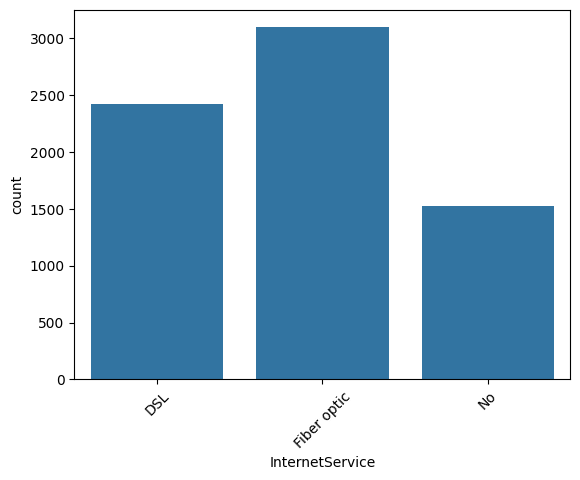

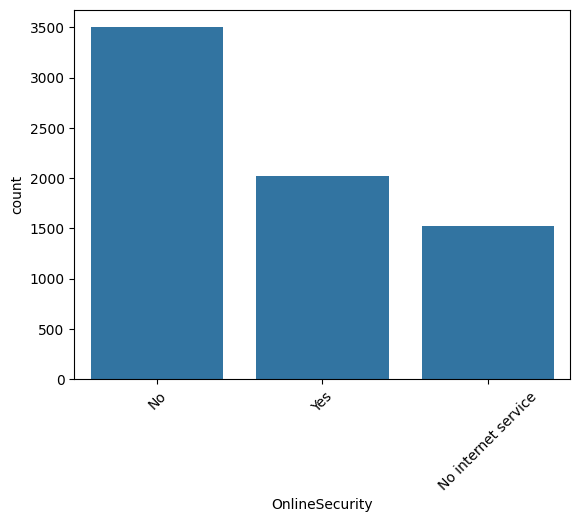

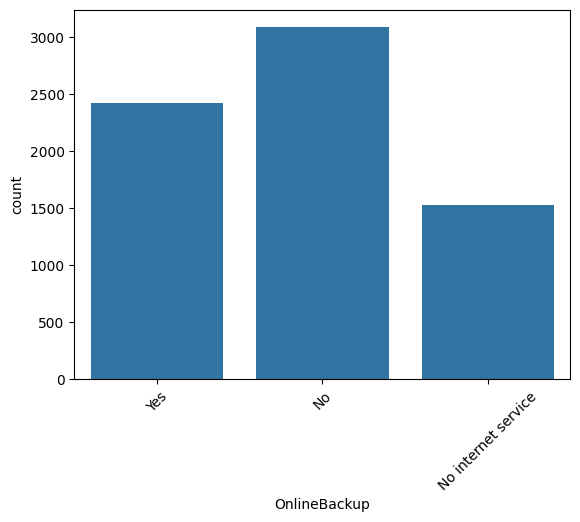

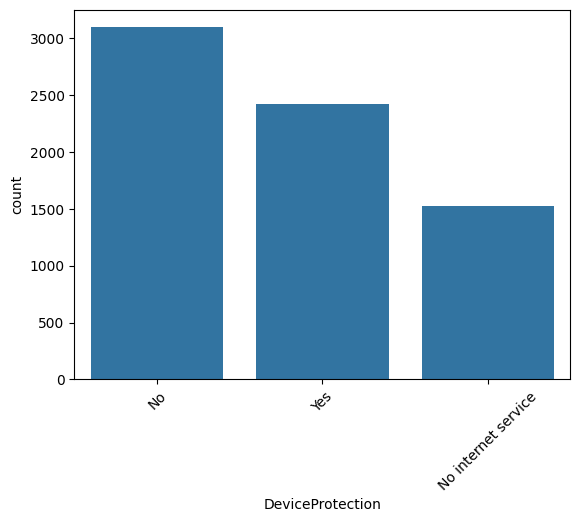

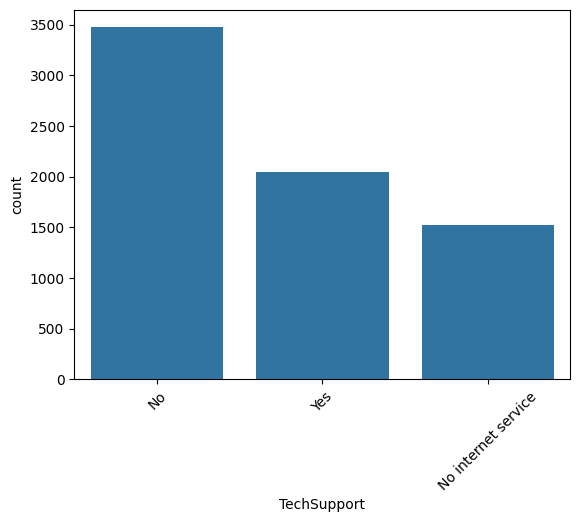

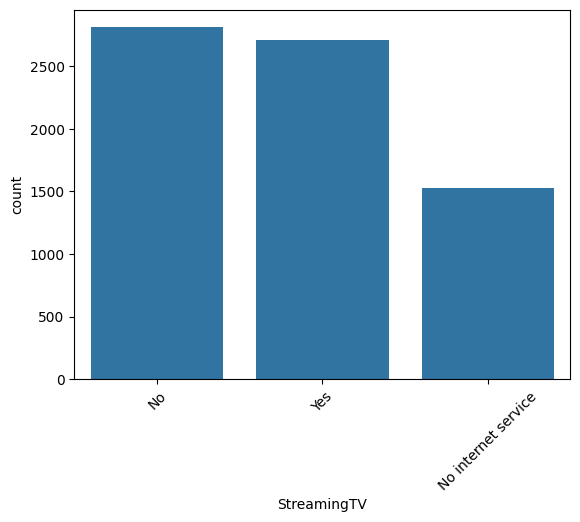

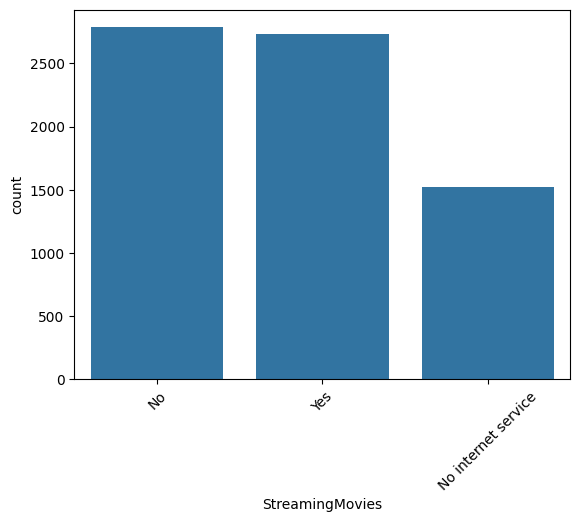

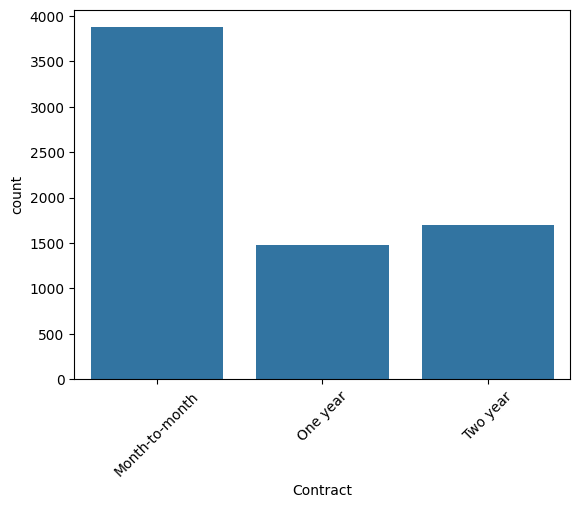

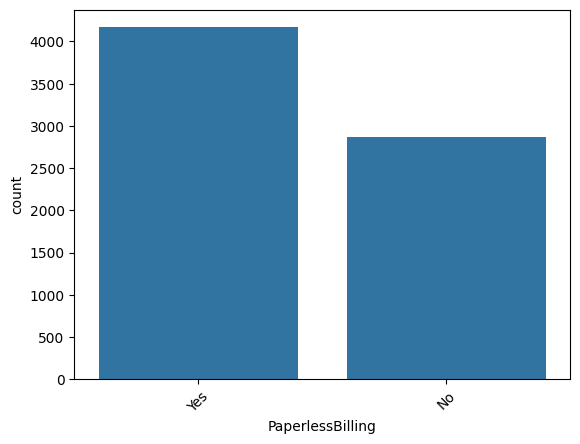

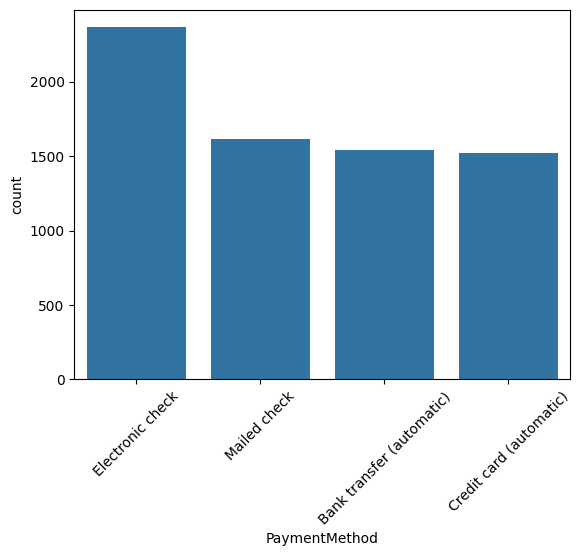

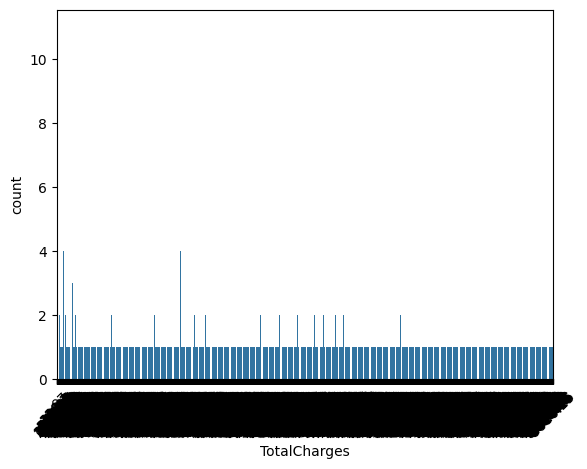

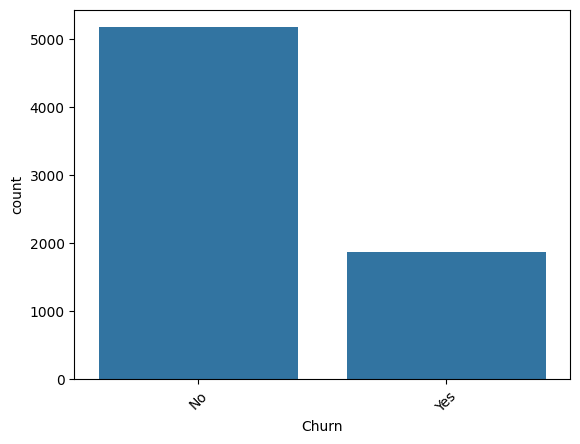

In [11]:
# Numerical
df.hist(figsize=(12,8))
plt.show()

# Categorical
for col in df.select_dtypes(include='object'):
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

**Bivariate Analysis**

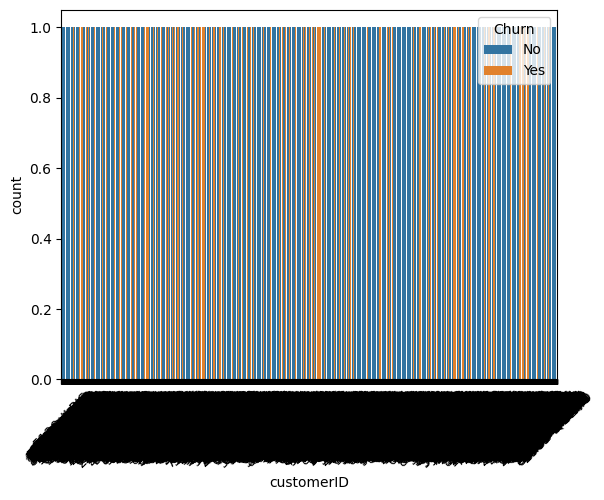

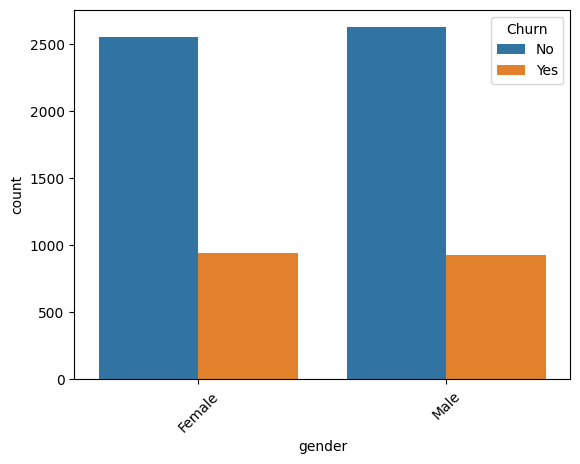

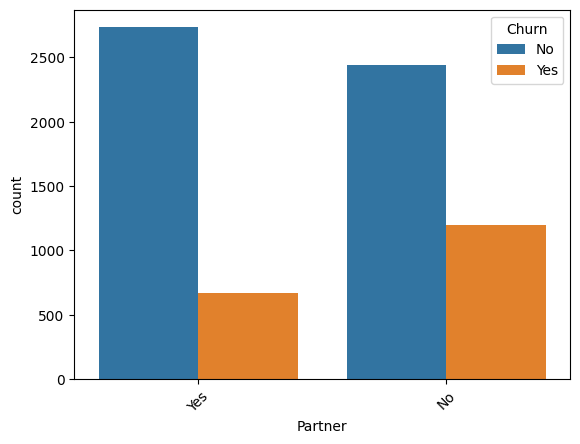

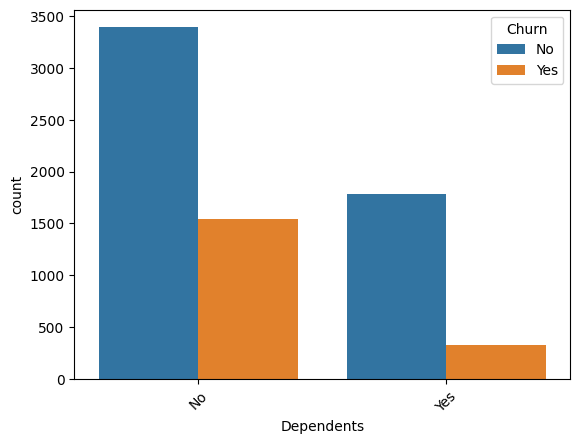

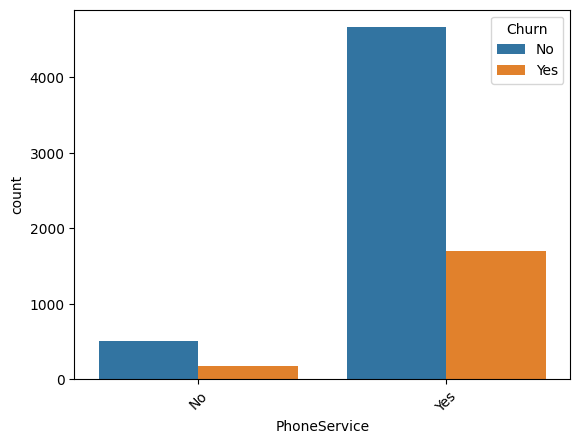

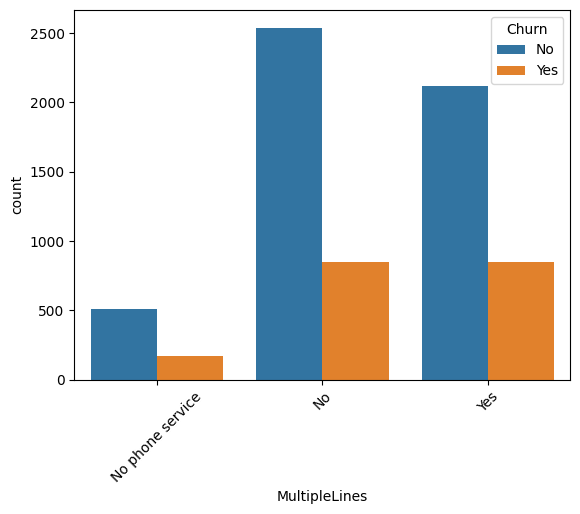

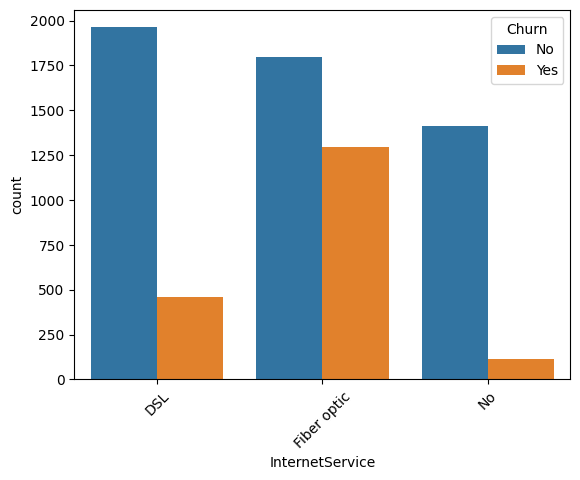

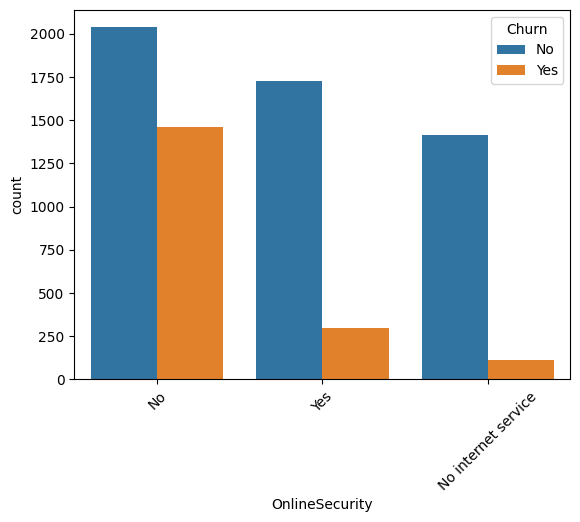

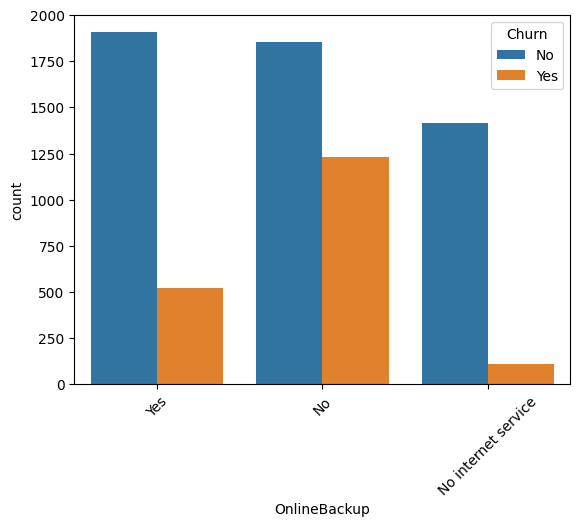

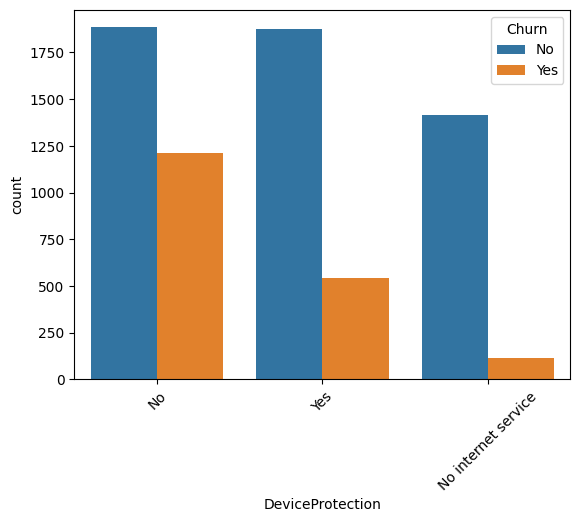

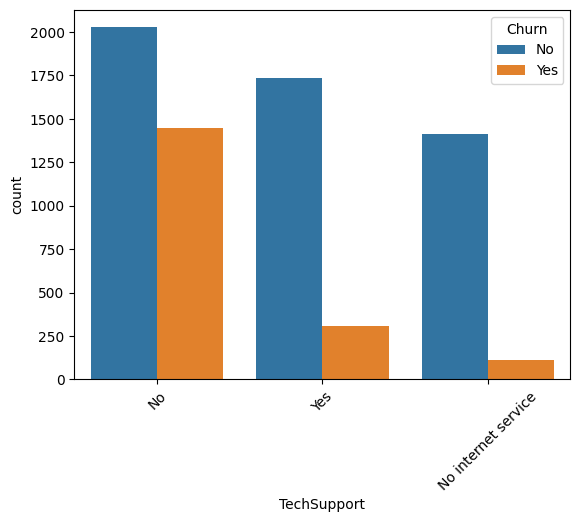

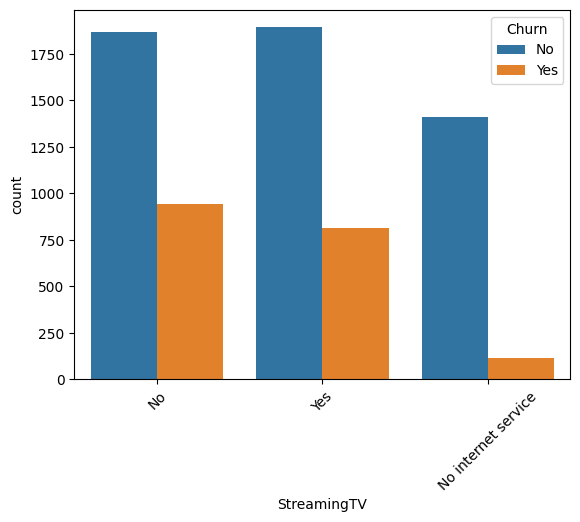

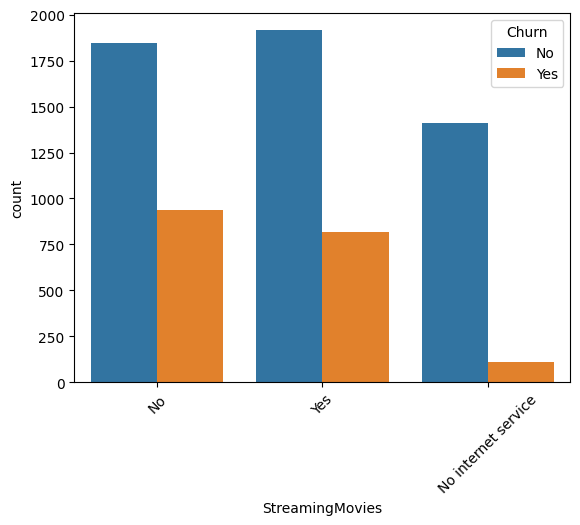

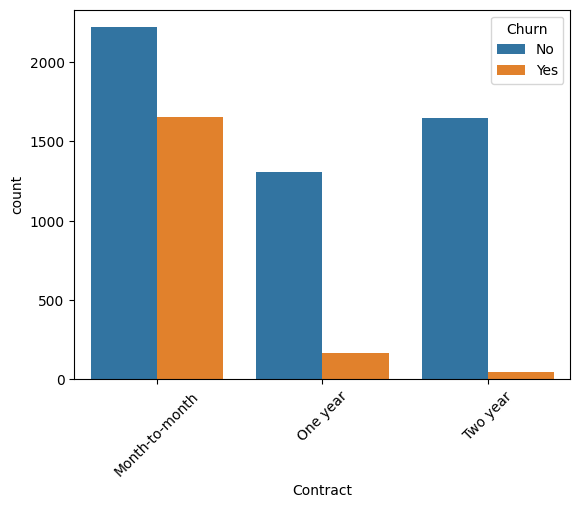

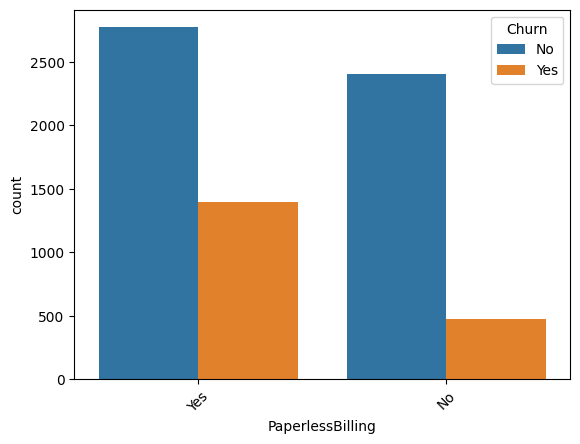

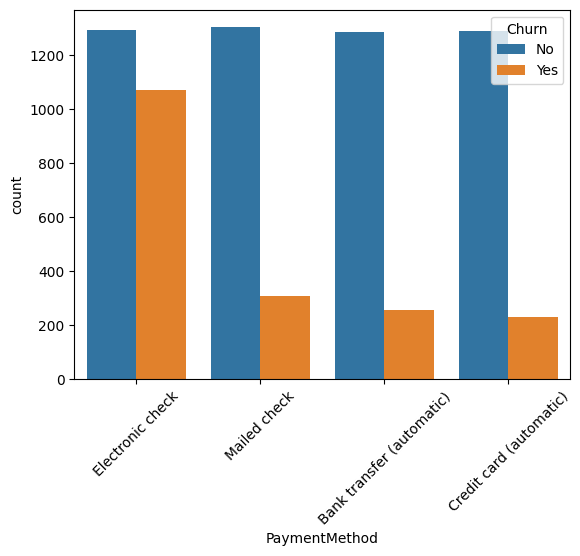

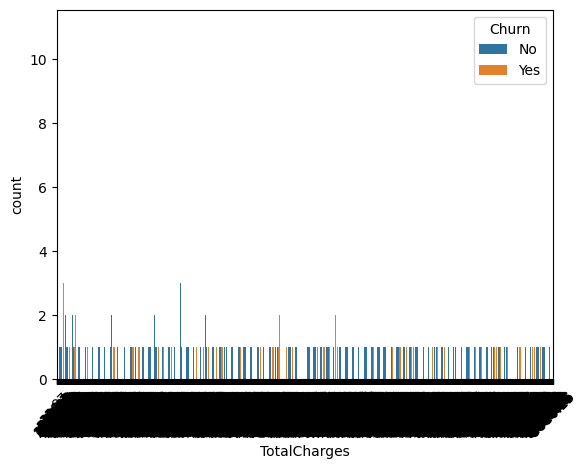

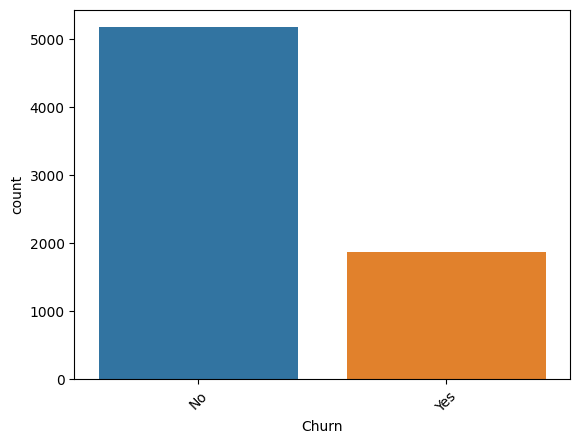

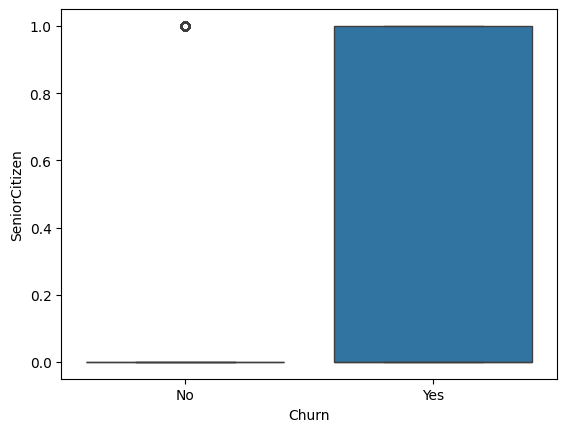

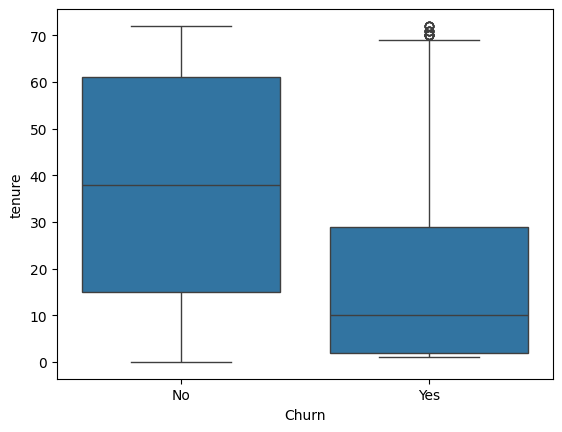

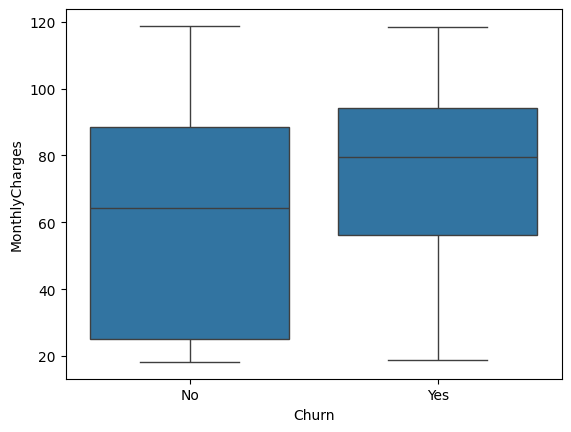

In [12]:
# Churn vs categorical
for col in df.select_dtypes(include='object'):
    sns.countplot(x=col, hue='Churn', data=df)
    plt.xticks(rotation=45)
    plt.show()

# Churn vs numerical
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    sns.boxplot(x='Churn', y=col, data=df)
    plt.show()

**Correlation Heatmap**

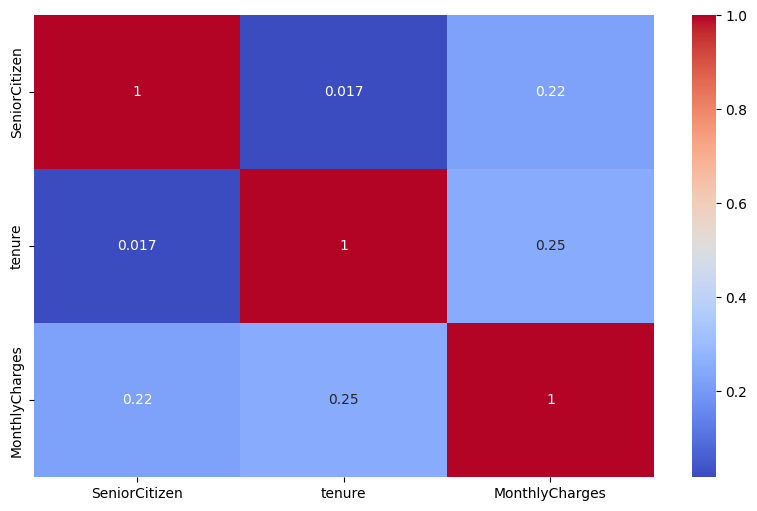

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

**Handle Outliers**

In [14]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Filter outliers
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) |
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

**Encoding**

In [15]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

**Scaling**

In [16]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

**Split Features & Target**

In [17]:
X = df_scaled.drop('Churn', axis=1)
y = df_scaled['Churn']

**Train-Test Split**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Handle Imbalance (SMOTE)**

In [19]:
smote = SMOTE()

# Identify the two unique scaled values in y_train
# Based on the kernel state, these are the scaled versions of 0 and 1.
scaled_val_for_0 = y_train.min()
scaled_val_for_1 = y_train.max()

# Create a mapping from scaled values back to original 0 and 1
y_train_discrete = y_train.replace({scaled_val_for_0: 0, scaled_val_for_1: 1}).astype(int)

# Apply SMOTE with the now discrete y_train
X_train, y_train = smote.fit_resample(X_train, y_train_discrete)

**Train Models**

In [20]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVC": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

# Convert y_test to discrete labels (0 or 1) using the already identified scaled values
# scaled_val_for_0 and scaled_val_for_1 are available in the kernel state from the previous cell.
y_test_discrete = y_test.replace({scaled_val_for_0: 0, scaled_val_for_1: 1}).astype(int)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test_discrete, y_pred),
        "Precision": precision_score(y_test_discrete, y_pred),
        "Recall": recall_score(y_test_discrete, y_pred),
        "F1": f1_score(y_test_discrete, y_pred),
        "ROC-AUC": roc_auc_score(y_test_discrete, model.predict_proba(X_test)[:,1])
    }

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.744285,0.457859,0.758491,0.571023,0.837806
KNN,0.678239,0.380952,0.694340,0.491979,0.739967
Decision Tree,0.729043,0.414861,0.505660,0.455782,0.649664
Random Forest,0.793395,0.540856,0.524528,0.532567,0.820994
SVC,0.767146,0.487245,0.720755,0.581431,0.813578
Gradient Boosting,0.789162,0.523810,0.664151,0.585691,0.841701


**Evaluation + Confusion Matrix**

In [21]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(confusion_matrix(y_test_discrete, y_pred))
    print(classification_report(y_test_discrete, y_pred))


Logistic Regression
[[678 238]
 [ 64 201]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.82       916
           1       0.46      0.76      0.57       265

    accuracy                           0.74      1181
   macro avg       0.69      0.75      0.69      1181
weighted avg       0.81      0.74      0.76      1181


KNN
[[617 299]
 [ 81 184]]
              precision    recall  f1-score   support

           0       0.88      0.67      0.76       916
           1       0.38      0.69      0.49       265

    accuracy                           0.68      1181
   macro avg       0.63      0.68      0.63      1181
weighted avg       0.77      0.68      0.70      1181


Decision Tree
[[727 189]
 [131 134]]
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       916
           1       0.41      0.51      0.46       265

    accuracy                           0.73      1181
   macro avg      

**Hyperparameter Tuning (Example: Random Forest)**

In [22]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)
best_model = grid.best_estimator_

{'max_depth': None, 'n_estimators': 200}


**Model Comparison**

In [23]:
comparison_df = pd.DataFrame(results).T
comparison_df.sort_values(by='F1', ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Gradient Boosting,0.789162,0.523810,0.664151,0.585691,0.841701
SVC,0.767146,0.487245,0.720755,0.581431,0.813578
Logistic Regression,0.744285,0.457859,0.758491,0.571023,0.837806
Random Forest,0.793395,0.540856,0.524528,0.532567,0.820994
KNN,0.678239,0.380952,0.694340,0.491979,0.739967
Decision Tree,0.729043,0.414861,0.505660,0.455782,0.649664


Best Model Selection

Typically:

Random Forest / Gradient Boosting performs best

Choose based on F1 Score + ROC-AUC

In [24]:
best_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

**Final Insights :**


High monthly charges → more churn

Month-to-month contracts → unstable customers

Short tenure → higher churn risk

No tech support → dissatisfaction

**Business Recommendations :**


Offer discounts on long-term contracts

Improve customer support quality

Identify high-risk users early

Provide loyalty rewards